## Autoregressive processes

$$
x_t = \rho x_{t-1} + \epsilon_t \qquad \epsilon_t \stackrel{\text{iid}}{\sim} \mathcal{N}\left(0, \sigma^2\right)
$$

### Simulating an AR(1) process

In [7]:
import numpy as np

def simulate_ar1(x0, rho, sigma, n, rng=None):
    """
    Simulates an AR(1) process.

    Parameters
    ----------
    x0 : float
        The initial value of the process.
    rho : float
        The autoregressive parameter.
    sigma : float
        The standard deviation of the noise term.
    n : int
        The number of time periods to simulate.
    rng : Generator, optional
        Random number generator to use.

    Returns
    -------
    numpy.ndarray
        An array of length `n` containing the simulated AR(1) process.
    """

    # Create an array to store the simulated values
    x = np.zeros(n)

    # Set the initial value
    x[0] = x0

    # Create RNG instance
    if rng is None:
        rng = np.random.default_rng(seed=1233)
        
    # Draw random shocks
    eps = rng.normal(0, sigma, n-1)

    # Simulate the AR(1) process
    for i in range(n-1):
        x[i+1] = rho * x[i] + eps[i]

    return x

In [9]:

seed = 1234
rng = np.random.default_rng(seed=seed)

# Initial value
x0 = 0.0

# Autoregressive parameter
rho = 0.9

# Standard deviation of the noise term
sigma = 0.1

# Number of periods to simulate
T = 100

# Simulate the AR(1) process
simulated_data = simulate_ar1(x0, 0.9, 1.0, T, rng)

Text(0.5, 1.0, 'Simulated AR(1) Process')

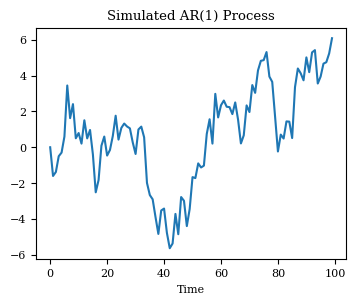

In [10]:
import matplotlib.pyplot as plt 

plt.plot(simulated_data)
plt.xlabel('Time')
plt.title('Simulated AR(1) Process')

Text(0.5, 1.0, 'Simulated AR(1) Processes')

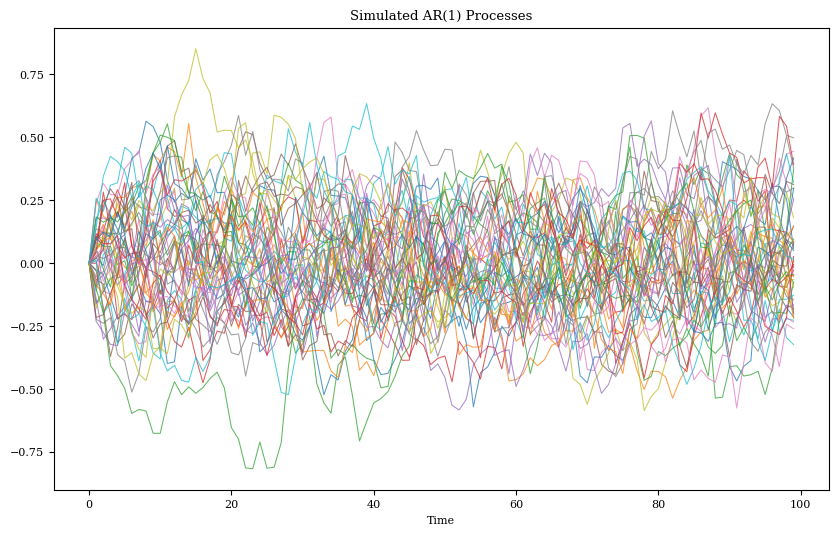

In [26]:
# Simulate 50 different sequences
N = 50

data = np.zeros((N, T))

for i in range(N):
    data[i, :] = simulate_ar1(x0, rho, sigma, T, rng)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(data.T, alpha=0.75, lw=0.75)
ax.set_xlabel('Time')
ax.set_title('Simulated AR(1) Processes')